# Exploratory Data Analysis (EDA) process
Is the process of understanding, summarizing , visualizing and diagnosing a dataset before building predictive or analytical models.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df1 = pd.read_csv("../data/raw/credit_card_transaction_dataset/fraudTrain.csv")

In [28]:
df2 = pd.read_csv("../data/raw/credit_card_transaction_dataset/fraudTest.csv")

NOTE: We would want to combine those splited (train and test) data that got from original source into a new one, then we splitting those data again.

In [29]:
# script to combine the two datasets into one
df = pd.concat([df1, df2], ignore_index=True)
# check the shape of the combined dataset
print(df.shape)


(1852394, 23)


In [30]:
# save the combined dataset to a new csv file and store in the "../data/processed" directory
df.to_csv("../data/processed/credit_card_transaction_dataset.csv", index=False)


## 1. Data Understanding
Before touching the data, we need to understand

What is the problem of project?
What is the target variable?
What type of variables do we have?
What does each column represent?

| Column Name | Description |
|---|---|
| `Unnamed: 0` | Row index saved from CSV export (not a real feature) |
| `trans_date_trans_time` | Transaction date and time |
| `cc_num` | Credit card number (customer/card identifier) |
| `merchant` | Merchant name where transaction happened |
| `category` | Merchant/transaction category (e.g., shopping, food) |
| `amt` | Transaction amount |
| `first` | Cardholder first name |
| `last` | Cardholder last name |
| `gender` | Cardholder gender |
| `street` | Cardholder street address |
| `city` | Cardholder city |
| `state` | Cardholder state |
| `zip` | Cardholder ZIP code |
| `lat` | Cardholder latitude |
| `long` | Cardholder longitude |
| `city_pop` | Population of cardholder city |
| `job` | Cardholder job/occupation |
| `dob` | Cardholder date of birth |
| `trans_num` | Unique transaction ID |
| `unix_time` | Transaction time in Unix timestamp format |
| `merch_lat` | Merchant latitude |
| `merch_long` | Merchant longitude |
| `is_fraud` | Target label: `1` = fraud, `0` = legitimate |


NOTE - The target variable: `is_fraud` 

## 2. Data Inspection
The first direct of interaction with data.

Tasks:

- Check shape (rows, columns)
- View first rows
- Check data types
- Identify missing values
- Identify duplicated rows 
- Check memory usage
- Outlier detection

In [31]:
# checking size of dataset
print("Size of dataset: ({}, {})".format(df.shape[0], df.shape[1]))

# checking first and last rows of dataset
print("First 5 rows of dataset:")
df.head()

Size of dataset: (1852394, 23)
First 5 rows of dataset:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [32]:
# checking missing values in dataset
print("Missing values in dataset:")
df.isnull().sum()

Missing values in dataset:


Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [33]:
# checking duplicated rows and memory usage of dataset
print("Number of duplicated rows in dataset: {}".format(df.duplicated().sum()))
print("Memory usage of dataset: {:.2f} MB".format(df.memory_usage(deep=True).sum() / 1024**2))

Number of duplicated rows in dataset: 0
Memory usage of dataset: 1648.16 MB


In [34]:
# checking data types of columns in dataset
print("Data types of columns in dataset:")
print(df.dtypes)

Data types of columns in dataset:
Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object


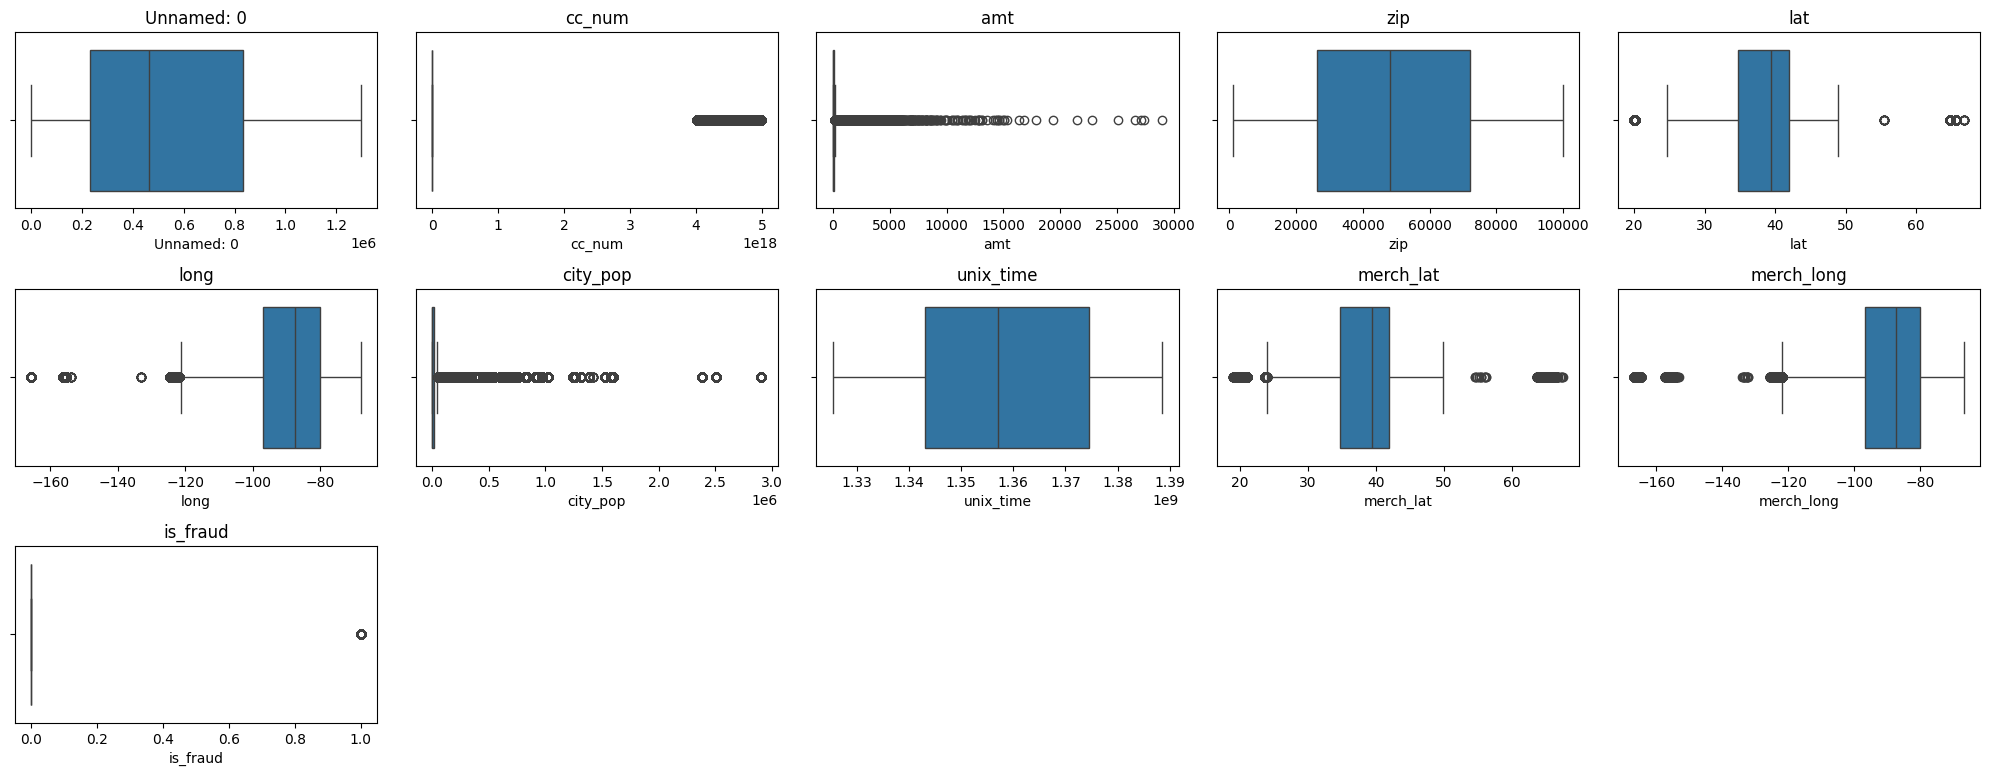

In [35]:
# outlier detection using boxplot for all numerical features
numerical_features = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(20, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(4, 5, i + 1)
    sns.boxplot(x=df[feature])
    plt.title(feature)
plt.tight_layout()
plt.show()

In [36]:
# splitting dataset into training 70%, test 20% and validation 10%
from sklearn.model_selection import train_test_split
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.3333, random_state=42, stratify=y_temp)
print("Size of training set: ({}, {})".format(X_train.shape[0], X_train.shape[1]))
print("Size of test set: ({}, {})".format(X_test.shape[0], X_test.shape[1]))
print("Size of validation set: ({}, {})".format(X_val.shape[0], X_val.shape[1]))

Size of training set: (1296675, 22)
Size of test set: (370497, 22)
Size of validation set: (185222, 22)


## Data Cleaning and Preprocessing

- Handling missing values (There is no any missing value in this dataset)
- Removing duplicates (There is no any duplicate in this dataset)
- Correcting data types (nothing wrong)
- Handling outliers
- Encoding categorical variables

In [37]:
# # removing outliers using IQR method for all numerical features
# numerical_features = df.select_dtypes(include=["float64", "int64"]).columns
# # checking size of dataset before removing outliers
# print("Size of dataset before removing outliers: ({}, {})".format(df.shape[0], df.shape[1]))
# for feature in numerical_features:
#     Q1 = df[feature].quantile(0.25)
#     Q3 = df[feature].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
#     df = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]
# # checking size of dataset after removing outliers
# print("Size of dataset after removing outliers: ({}, {})".format(df.shape[0], df.shape[1]))

# # Plot the outlier detection results using boxplot for all numerical features after removing outliers
# numerical_features = df.select_dtypes(include=["float64", "int64"]).columns
# plt.figure(figsize=(20, 10))
# for i, feature in enumerate(numerical_features):
#     plt.subplot(4, 5, i + 1)
#     sns.boxplot(x=df[feature])
#     plt.title(feature)
# plt.tight_layout()
# plt.show()

In [38]:
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["dob"] = pd.to_datetime(df["dob"])
df = df.astype({"cc_num": "object", "zip": "object"})

In [39]:
df.dtypes

Unnamed: 0                        int64
trans_date_trans_time    datetime64[ns]
cc_num                           object
merchant                         object
category                         object
amt                             float64
first                            object
last                             object
gender                           object
street                           object
city                             object
state                            object
zip                              object
lat                             float64
long                            float64
city_pop                          int64
job                              object
dob                      datetime64[ns]
trans_num                        object
unix_time                         int64
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
dtype: object

## Univariate Analysis

We need to understand by analyze on each ralevant variable indenpendently.

For Numerical Variables: 
- Mean, Median, Mode, Standard Deviation, Min / Max, Distribution shape (skewed, normal), and outliers.

Visualization
- Histogram, BoxPlot, Density Plot, etc. 

For Categorical Variables:
- Frequency Count
- Precentage distribution

Basicially just answer "what does each variable look like by itself ? "


### Anaylze on Target Variable 

In [40]:
# counting the number of fraudulent and non-fraudulent transactions in the dataset
print("Number of fraudulent transactions: {}".format(df[df["is_fraud"] == 1].shape[0]))
print("Number of non-fraudulent transactions: {}".format(df[df["is_fraud"] == 0].shape[0]))

Number of fraudulent transactions: 9651
Number of non-fraudulent transactions: 1842743


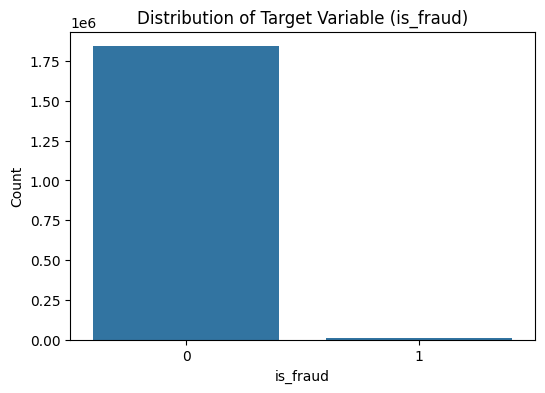

In [41]:
# checking distribution of target variable
plt.figure(figsize=(6, 4))
sns.countplot(x=df["is_fraud"])
plt.title("Distribution of Target Variable (is_fraud)")
plt.xlabel("is_fraud")
plt.ylabel("Count")
plt.show()

### Analyze on Numerical Variable

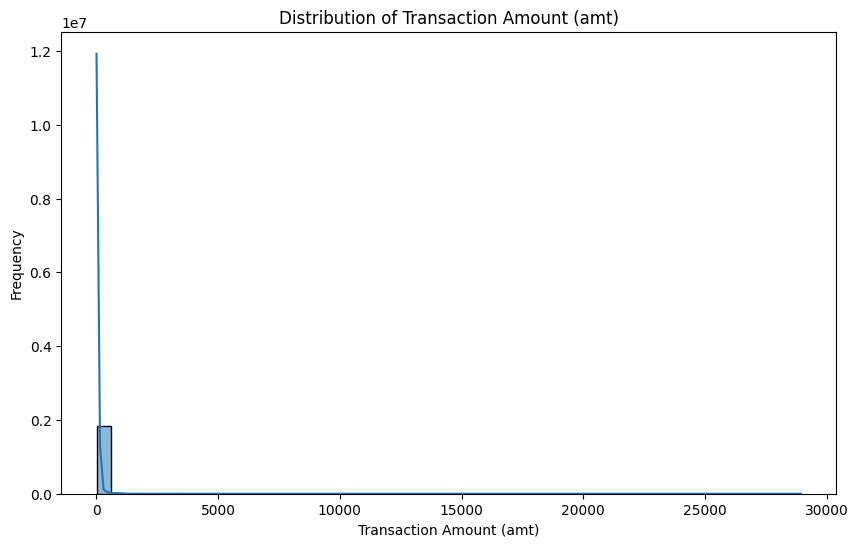

In [42]:
# checking on the distribution of the "amt" feature
plt.figure(figsize=(10, 6))
sns.histplot(df["amt"], bins=50, kde=True)
plt.title("Distribution of Transaction Amount (amt)")
plt.xlabel("Transaction Amount (amt)")
plt.ylabel("Frequency")
plt.show()


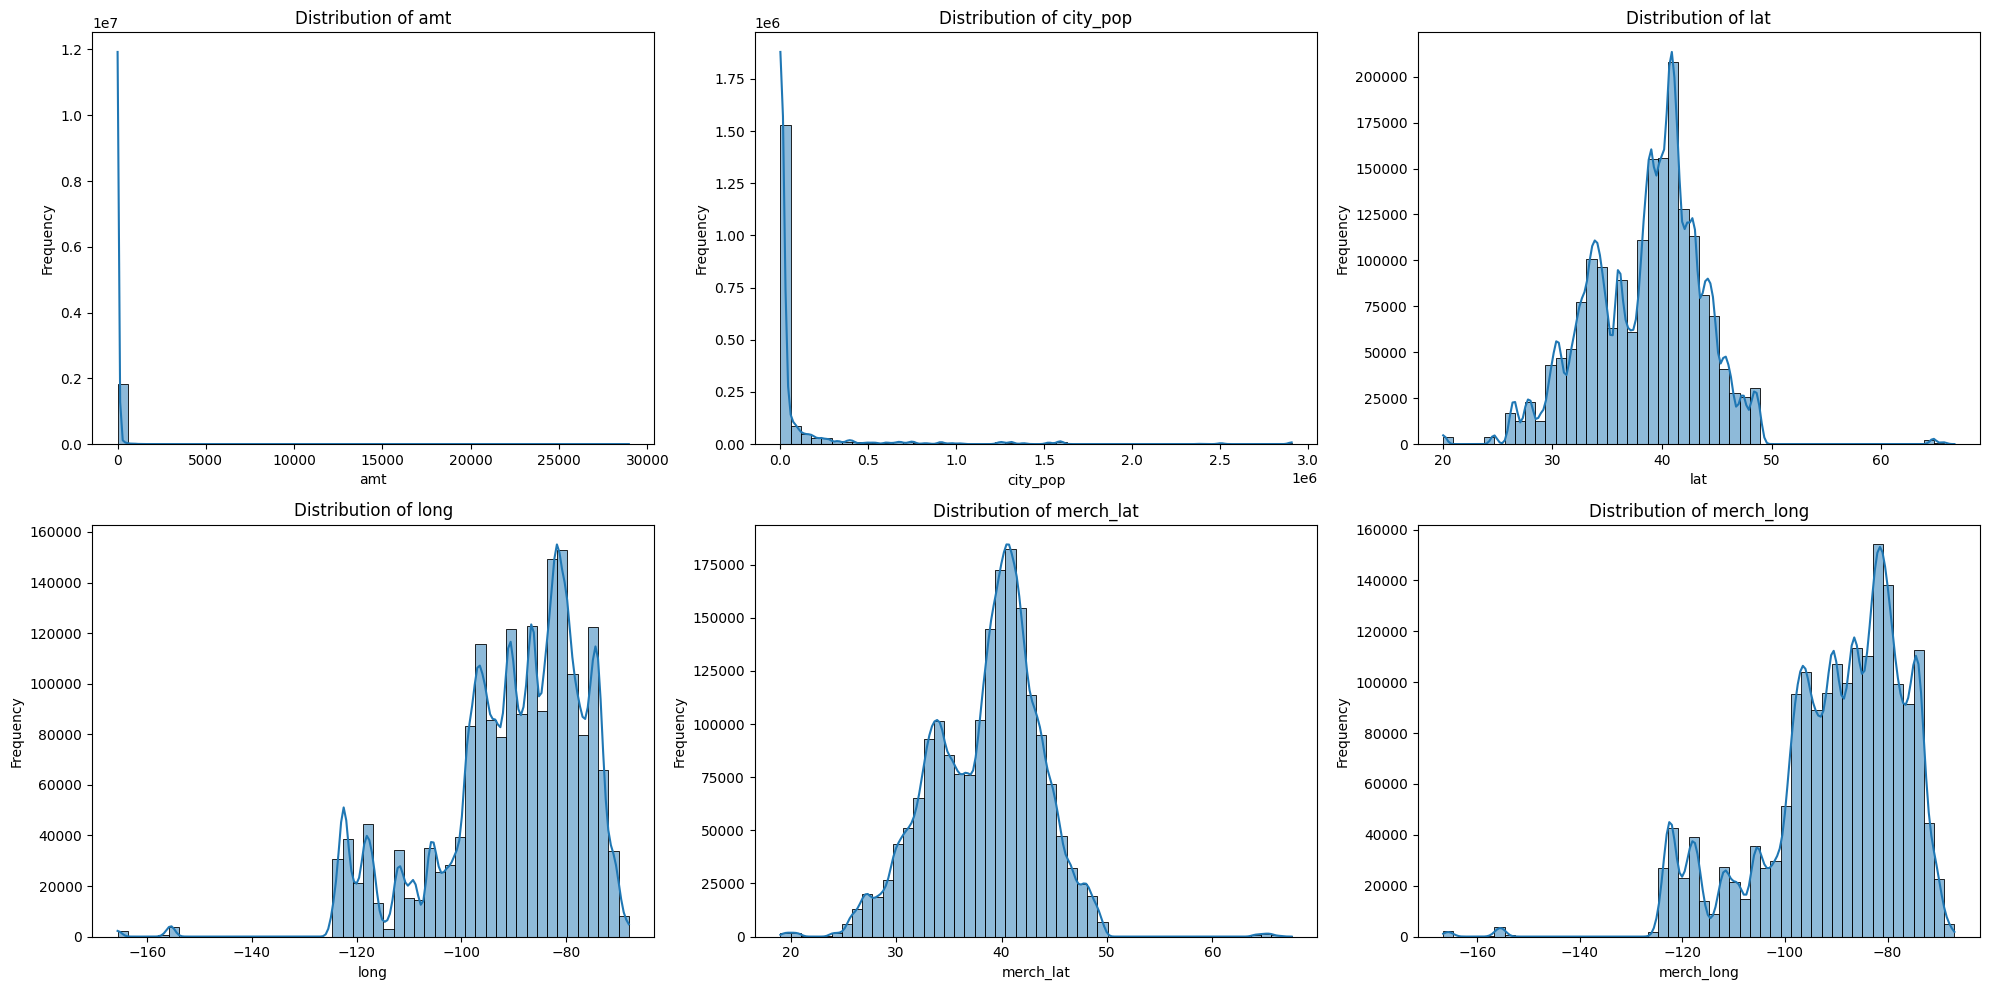

In [43]:
# exploring each "amt", "city_pop", "lat", "long", "merch_lat", "merch_long" features
numerical_features = ["amt", "city_pop", "lat", "long", "merch_lat", "merch_long"]
plt.figure(figsize=(20, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[feature], bins=50, kde=True)
    plt.title("Distribution of {}".format(feature))
    plt.xlabel(feature)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Analyze on Categorial variables

In [44]:
# exploring "category", "merchant", "gender", "state", "job" features
category_features = ["category", "gender"]

## Bivariate Analysis (Relationship Between Two Variables)

Common Combinations:
- Numerical vs Numerical (Correlation, Scatter Plot)
- Categorical vs Numerical (Grouped mean, Boxplot by category, ANOVA)
- Categorical vs Categorical (Crosstab, Chi-sware test, stacked bar chart)

It helps us to answer "what influences what or how they interact with each other? "

## Basic Feature Engineering
Time Features
- Extract hour from:
  - `trans_date_trans_time`
- Extract day of week from:
  - `trans_date_trans_time`
- Extract month from:
  - `trans_date_trans_time`

In [45]:
df["trans_hour"] = df["trans_date_trans_time"].dt.hour
df["trans_month"] = df["trans_date_trans_time"].dt.month
df["trans_dayofweek"] = df["trans_date_trans_time"].dt.dayofweek

User Age
- Compute age from:
  - `dob`

In [46]:
df["age"] = (pd.to_datetime("today") - df["dob"]).dt.days // 365

Transaction Distance
- Compute distance using:
  - `lat`
  - `long`
  - `merch_lat`
  - `merch_long`

In [47]:
df["distance"] = ((df["lat"] - df["merch_lat"]) ** 2 + (df["long"] - df["merch_long"]) ** 2) ** 0.5

### Analysis
#### Numerical vs Numerical
- Correlation matrix
  - `amt`
  - `city_pop`
  - `lat`
  - `long`
  - `merch_lat`
  - `merch_long`
  - `unix_time`

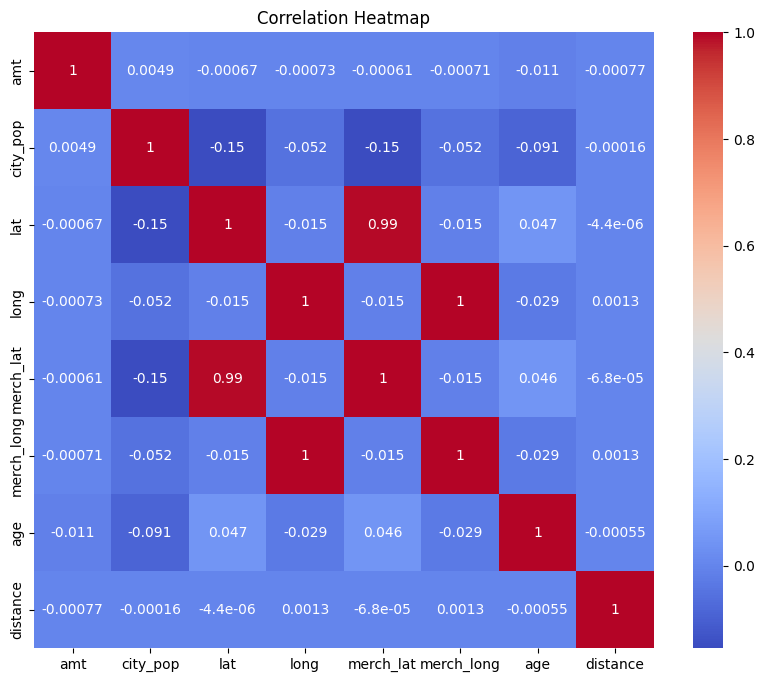

In [48]:
cols = [
    "amt",
    "city_pop",
    "lat",
    "long",
    "merch_lat",
    "merch_long",
    "age",
    "distance"
]

corr = df[cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Most numerical variables show near-zero correlation with transaction amount, indicating that transaction value is largely independent of geographic location, customer age, and city population.

#### Numerical vs Target
- Transaction amount vs fraud
  - `amt` vs `is_fraud`
- Distance vs fraud
  - `distance` vs `is_fraud`
- Population vs fraud
  - `city_pop` vs `is_fraud`
- Transaction hour vs fraud
  - `hour` vs `is_fraud`

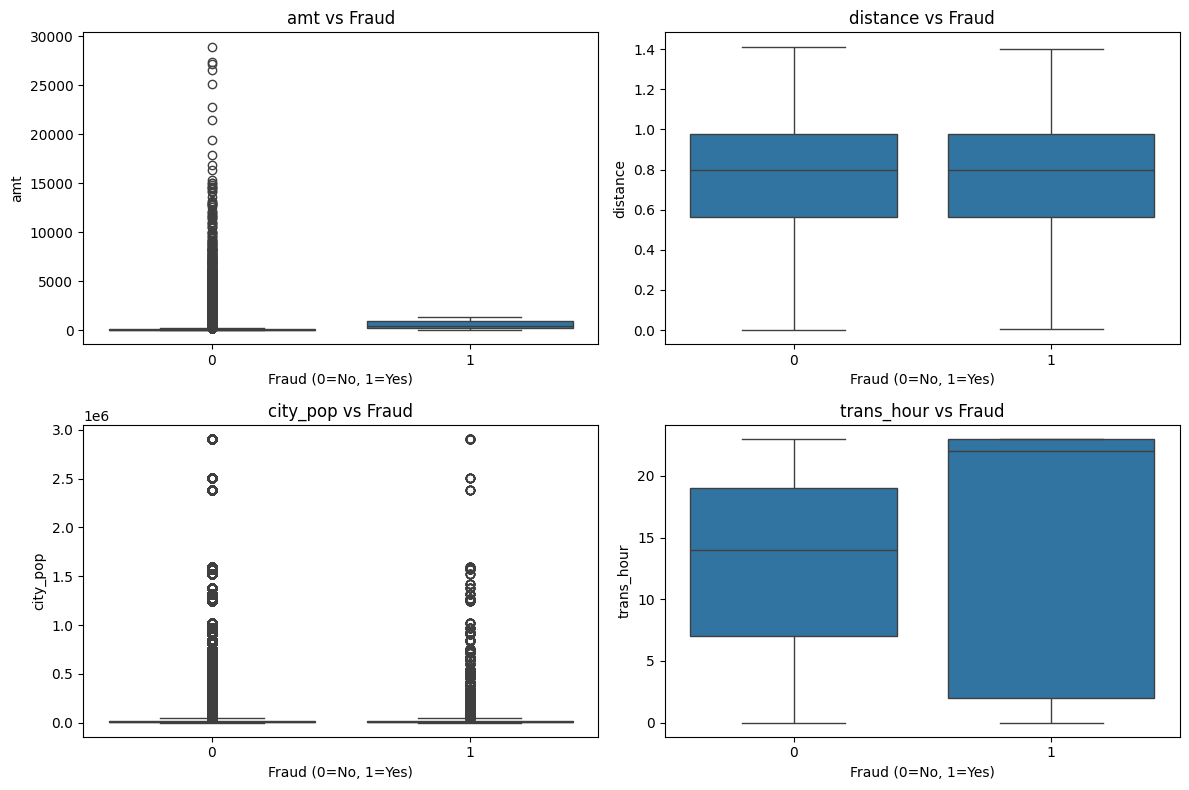

In [49]:
features = ["amt", "distance", "city_pop", "trans_hour"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(features):
    ax = axes[i//2, i%2]
    sns.boxplot(x="is_fraud", y=col, data=df, ax=ax)
    ax.set_title(f"{col} vs Fraud")
    ax.set_xlabel("Fraud (0=No, 1=Yes)")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

#### Categorical vs Target
- Category fraud rate
  - `category` vs `is_fraud`
- Merchant fraud rate
  - `merchant` vs `is_fraud`
- Gender fraud rate
  - `gender` vs `is_fraud`
- Job fraud rate
  - `job` vs `is_fraud`
- State fraud rate
  - `state` vs `is_fraud`

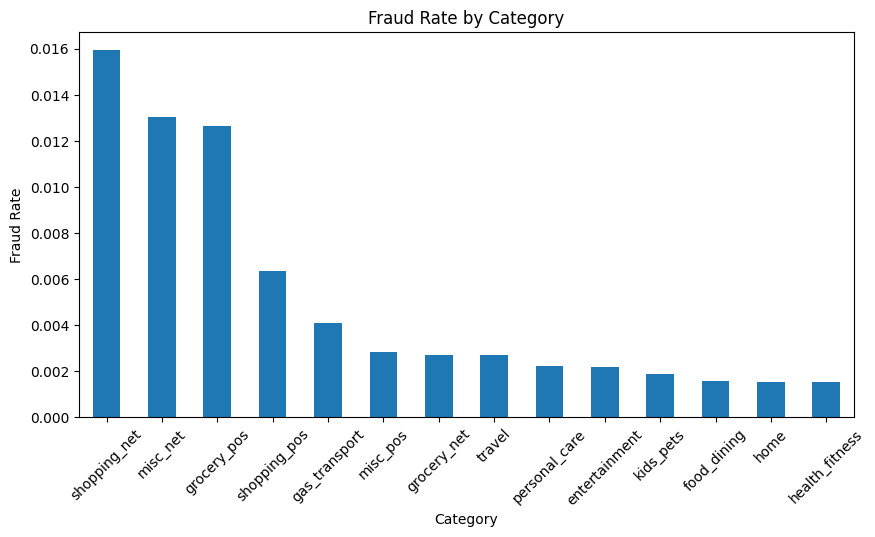

In [50]:
fraud_rate_category = df.groupby("category")["is_fraud"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
fraud_rate_category.plot(kind="bar")
plt.title("Fraud Rate by Category")
plt.ylabel("Fraud Rate")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.show()

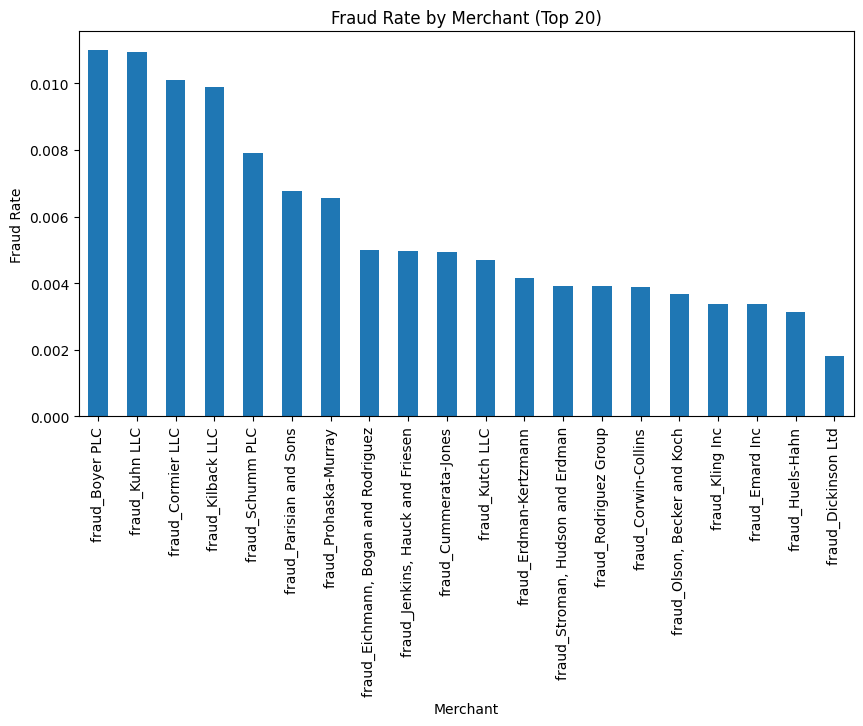

In [51]:
top_merchants = df["merchant"].value_counts().head(20).index

fraud_rate_merchant = (
    df[df["merchant"].isin(top_merchants)]
    .groupby("merchant")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
fraud_rate_merchant.plot(kind="bar")
plt.title("Fraud Rate by Merchant (Top 20)")
plt.ylabel("Fraud Rate")
plt.xlabel("Merchant")
plt.xticks(rotation=90)
plt.show()

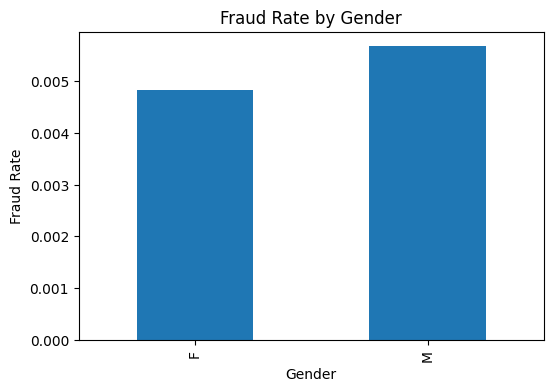

In [52]:
fraud_rate_gender = df.groupby("gender")["is_fraud"].mean()

plt.figure(figsize=(6,4))
fraud_rate_gender.plot(kind="bar")
plt.title("Fraud Rate by Gender")
plt.ylabel("Fraud Rate")
plt.xlabel("Gender")
plt.show()

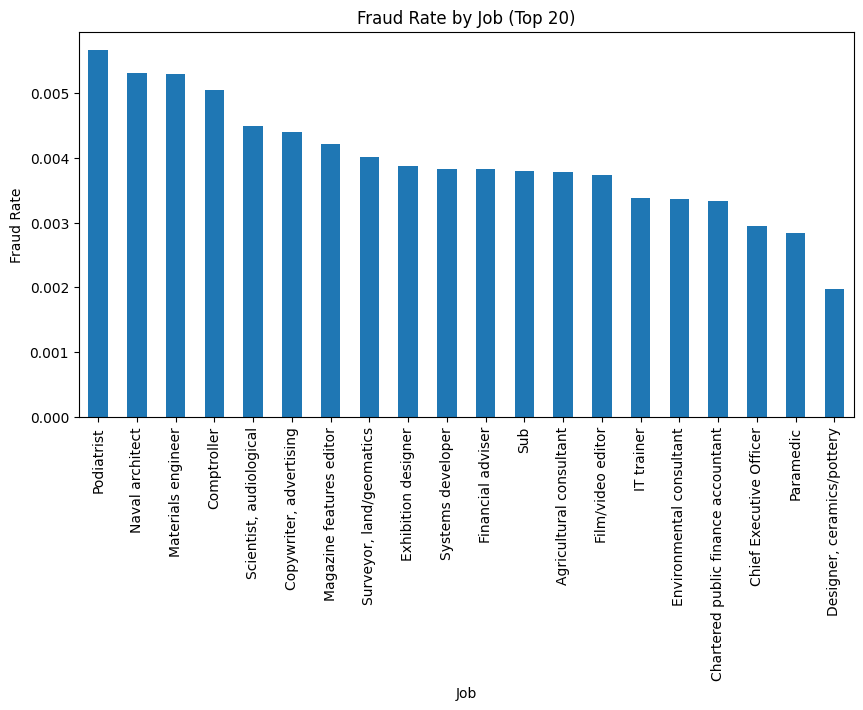

In [53]:
top_jobs = df["job"].value_counts().head(20).index

fraud_rate_job = (
    df[df["job"].isin(top_jobs)]
    .groupby("job")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
fraud_rate_job.plot(kind="bar")
plt.title("Fraud Rate by Job (Top 20)")
plt.ylabel("Fraud Rate")
plt.xlabel("Job")
plt.xticks(rotation=90)
plt.show()

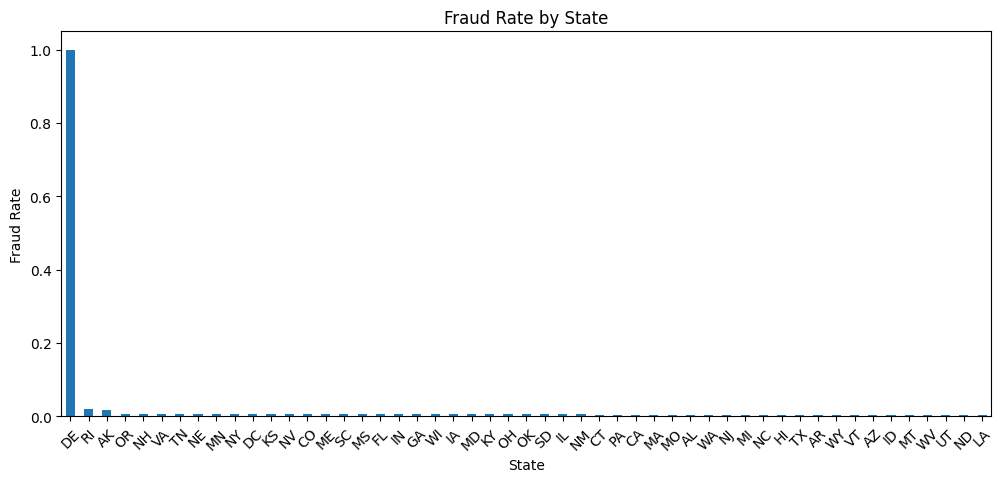

In [54]:
fraud_rate_state = df.groupby("state")["is_fraud"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
fraud_rate_state.plot(kind="bar")
plt.title("Fraud Rate by State")
plt.ylabel("Fraud Rate")
plt.xlabel("State")
plt.xticks(rotation=45)
plt.show()

## Multivariate Analysis
Analyze relationship among multiple variables simultaneously.

Techniques:
- Correlation matrix
- Heatmap
- Pairplot
- Grouped aggregations
- Pivot tables

It can helps us to answer "what patterns emerge when everything interacts?"

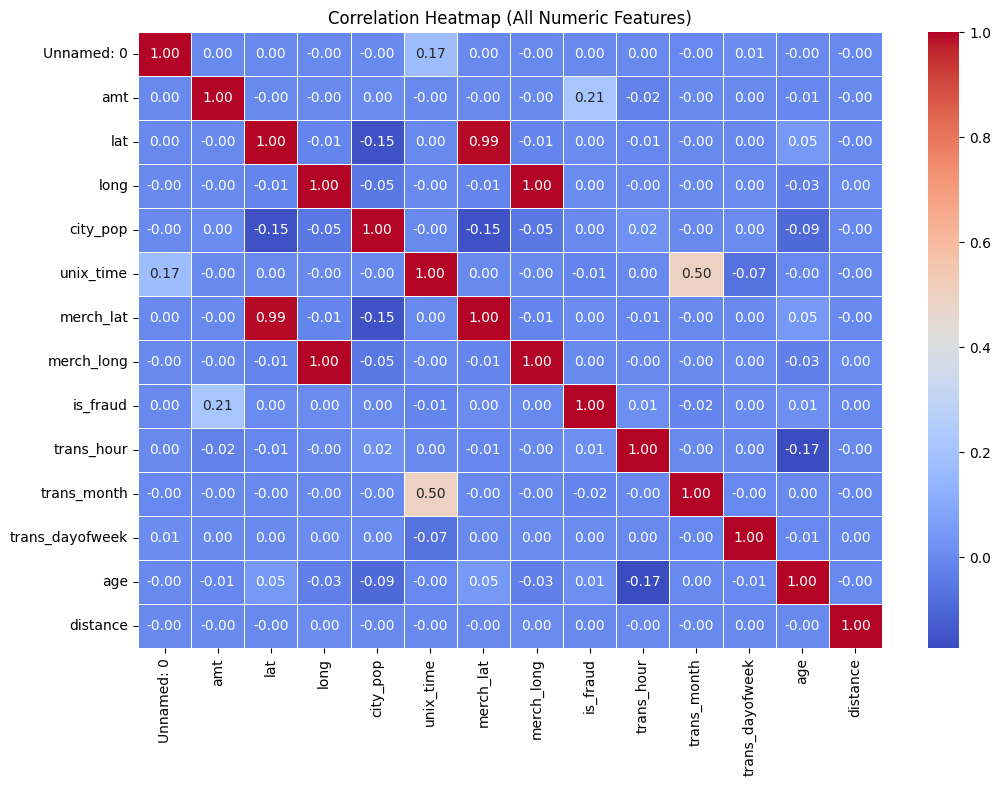

In [55]:
# Select numeric columns automatically
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap (All Numeric Features)")
plt.show()

based onn this heatmap cor we can keep only either merch_long or long and either merch_lat or lat

In [56]:
#group data by category and is_fraoud then calculate amount transection
df.groupby(['category','is_fraud'])['amt'].mean()

category        is_fraud
entertainment   0            63.181494
                1           504.794384
food_dining     0            50.884652
                1           120.678829
gas_transport   0            63.688542
                1            12.231256
grocery_net     0            53.801150
                1            12.046914
grocery_pos     0           114.135071
                1           312.237262
health_fitness  0            54.139079
                1            20.277622
home            0            57.886732
                1           257.479094
kids_pets       0            57.601378
                1            18.485296
misc_net        0            70.689738
                1           798.654577
misc_pos        0            62.252334
                1           212.716894
personal_care   0            48.096911
                1            26.110207
shopping_net    0            72.194496
                1           998.128725
shopping_pos    0            73.799294


In [57]:
#calculate the distrance
import numpy as np

df['distance'] = np.sqrt(
    (df['lat'] - df['merch_lat'])**2 +
    (df['long'] - df['merch_long'])**2
)

In [58]:
#extract transection hours
df['hour'] = df['trans_date_trans_time'].dt.hour

In [59]:
#age
df['age'] = 2020 - df['dob'].dt.year

In [60]:
numeric_df = df.select_dtypes(include='number')

corr = numeric_df.corr()

corr['is_fraud'].sort_values(ascending=False)

is_fraud           1.000000
amt                0.209308
trans_hour         0.013196
hour               0.013196
age                0.011103
trans_dayofweek    0.004562
lat                0.002904
merch_lat          0.002778
long               0.001022
merch_long         0.000999
Unnamed: 0         0.000524
distance           0.000458
city_pop           0.000325
unix_time         -0.013329
trans_month       -0.016417
Name: is_fraud, dtype: float64

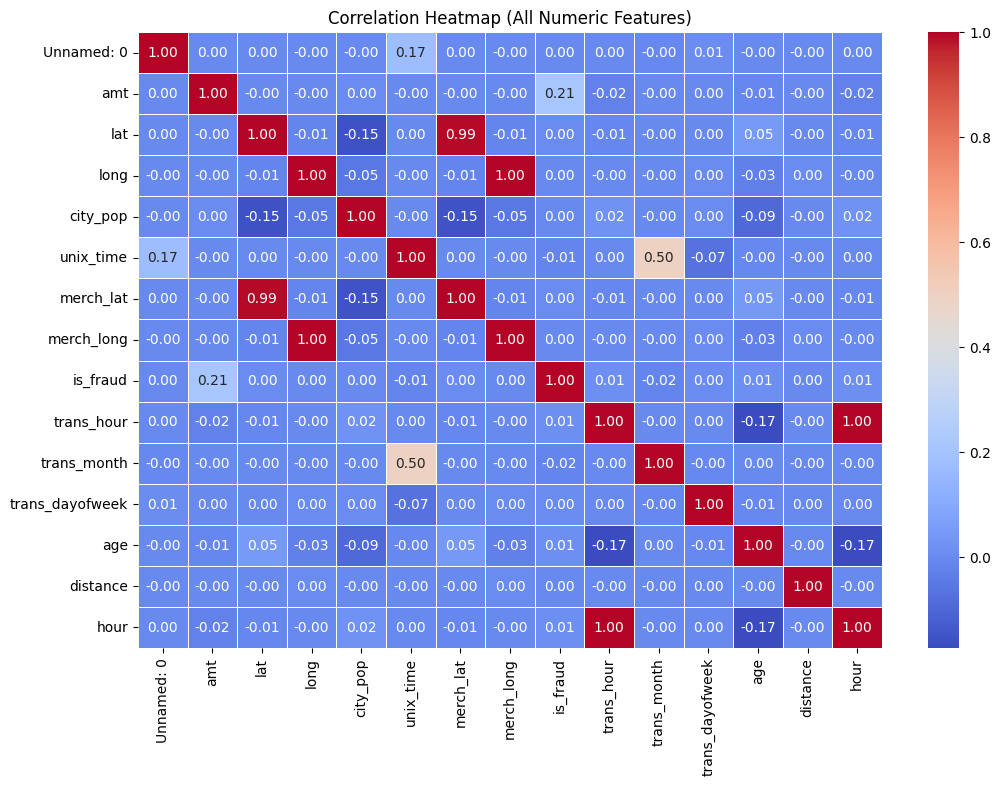

In [61]:
# Compute correlation
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",   
    linewidths=0.5
)

plt.title("Correlation Heatmap (All Numeric Features)")
plt.show()

In [62]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_month,trans_dayofweek,age,distance,hour
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,1325376018,36.011293,-82.048315,0,0,1,1,32,0.872830,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,1325376044,49.159047,-118.186462,0,0,1,1,42,0.272310,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,1325376051,43.150704,-112.154481,0,0,1,1,58,0.975845,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,1325376076,47.034331,-112.561071,0,0,1,1,53,0.919802,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,1325376186,38.674999,-78.632459,0,0,1,1,34,0.868505,0


# feature selection

- amt
- merchant
- category
- unix_time (to be finalized)
- gender
- lat 
- long
- state
- city
- zip
- city-pop
- dob (derived to age)
- trans_date_trans_time (derived to hour, day_of_week, is_weekend)
- job
- merch-lat
- merch-long
- is_fraud 

The keep columns: 
- amt: amount per transaction 
- is_weekday: binary 0 and 1
- hours: 0-24
- merchant
- category
- ccnum
- age: 2020